In [49]:
import os
import yaml
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ultralytics import YOLO
import mlflow

## Dataset Configuration

In [50]:
DATASET_ROOT = Path("../dataset/")
DATA_YAML = DATASET_ROOT / "data.yaml"

assert DATA_YAML.exists(), f"data.yaml not found at {DATA_YAML}"

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

print("data.yaml contents:")
print(yaml.dump(data_cfg, sort_keys=False))

data.yaml contents:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 6
names:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches
roboflow:
  workspace: neudefectdetection
  project: neu-surface-defect-pohqa
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/neudefectdetection/neu-surface-defect-pohqa/dataset/1



In [51]:
# Class names — pulled directly from the Roboflow export
CLASS_NAMES = data_cfg["names"]
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## Explore the Dataset

In [52]:
def count_images(split: str) -> int:
    folder_name = "valid" if split == "val" else split
    
    img_dir = DATASET_ROOT / folder_name / "images"
    
    if not img_dir.exists():
        print(f"Warning: Folder not found at {img_dir}")
        return 0
        
    return len([f for f in img_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")])

split_counts = {split: count_images(split) for split in ["train", "val", "test"]}

df_splits = pd.DataFrame(list(split_counts.items()), columns=["split", "image_count"])
df_splits["percentage"] = (df_splits["image_count"] / df_splits["image_count"].sum() * 100).round(1)
df_splits

,split,image_count,percentage
0,train,3780,87.5
1,val,360,8.3
2,test,179,4.1


/var/folders/_2/jy5tz6gd3psg08g74s135tw40000gn/T/ipykernel_62853/2878703334.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_splits.plot(kind="bar", x="split", y="image_count", legend=False,


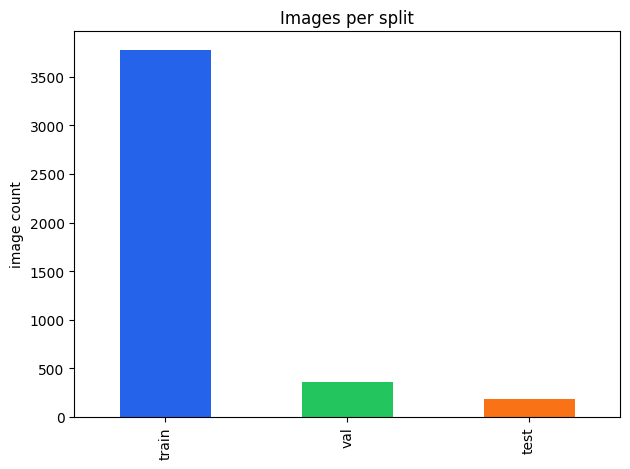

In [53]:
df_splits.plot(kind="bar", x="split", y="image_count", legend=False,
                title="Images per split", color=["#2563eb", "#22c55e", "#f97316"])
plt.ylabel("image count")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Class distribution


In [54]:
import os
from pathlib import Path
from collections import Counter
import pandas as pd

# 1. Ensure this points exactly to your train labels folder
train_labels_dir = DATASET_ROOT / "train" / "labels"

train_dist = Counter()

# 2. Scan and parse the YOLO label files
if train_labels_dir.exists():
    for label_file in train_labels_dir.glob("*.txt"):
        try:
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:  # Ensure line isn't empty
                        class_id = int(parts[0])
                        train_dist[class_id] += 1
        except Exception as e:
            pass  # Skips corrupted or unreadable text files safely
else:
    print(f"❌ Target folder not found: {train_labels_dir.resolve()}")

# 3. Build and display the distribution table
df_dist = pd.DataFrame([
    {"class_id": cid, "class_name": CLASS_NAMES[cid], "count": count}
    for cid, count in sorted(train_dist.items())
], columns=["class_id", "class_name", "count"])

if not df_dist.empty and df_dist["count"].sum() > 0:
    df_dist["percentage"] = (df_dist["count"] / df_dist["count"].sum() * 100).round(1)
    df_dist = df_dist.sort_values("count", ascending=False)
    print("✅ Successfully calculated class distribution!")
else:
    df_dist["percentage"] = 0.0
    print("⚠️ Warning: Still no labels found. Double-check that CLASS_NAMES matches your data.yaml.")

df_dist

✅ Successfully calculated class distribution!


,class_id,class_name,count,percentage
1,1,inclusion,2082,23.5
2,2,patches,1929,21.8
0,0,crazing,1488,16.8
4,4,rolled-in_scale,1296,14.6
5,5,scratches,1140,12.9
3,3,pitted_surface,921,10.4


/var/folders/_2/jy5tz6gd3psg08g74s135tw40000gn/T/ipykernel_62853/1088179929.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df_dist.sort_values("count").plot(


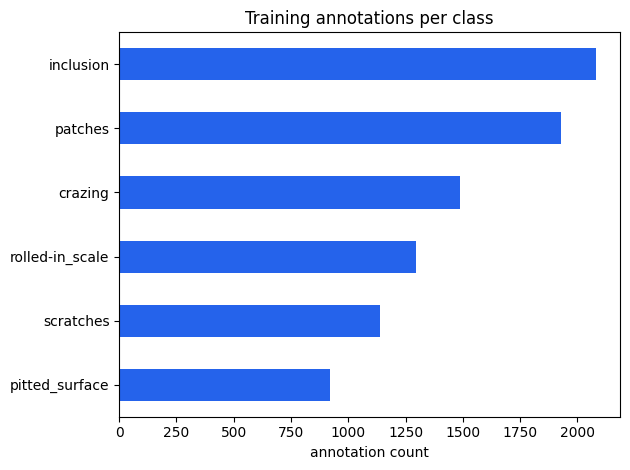


Imbalance ratio (max class / min class): 2.26x
✓ Classes are reasonably balanced.


In [55]:
df_dist.sort_values("count").plot(
    kind="barh", x="class_name", y="count", legend=False,
    title="Training annotations per class", color="#2563eb"
)
plt.xlabel("annotation count")
plt.ylabel("")
plt.tight_layout()
plt.show()

imbalance_ratio = df_dist["count"].max() / df_dist["count"].min()
print(f"\nImbalance ratio (max class / min class): {imbalance_ratio:.2f}x")
if imbalance_ratio > 3:
    print("⚠ Significant class imbalance — consider class weighting or augmentation for minority classes.")
else:
    print("✓ Classes are reasonably balanced.")

## Visualize sample images with bounding boxes

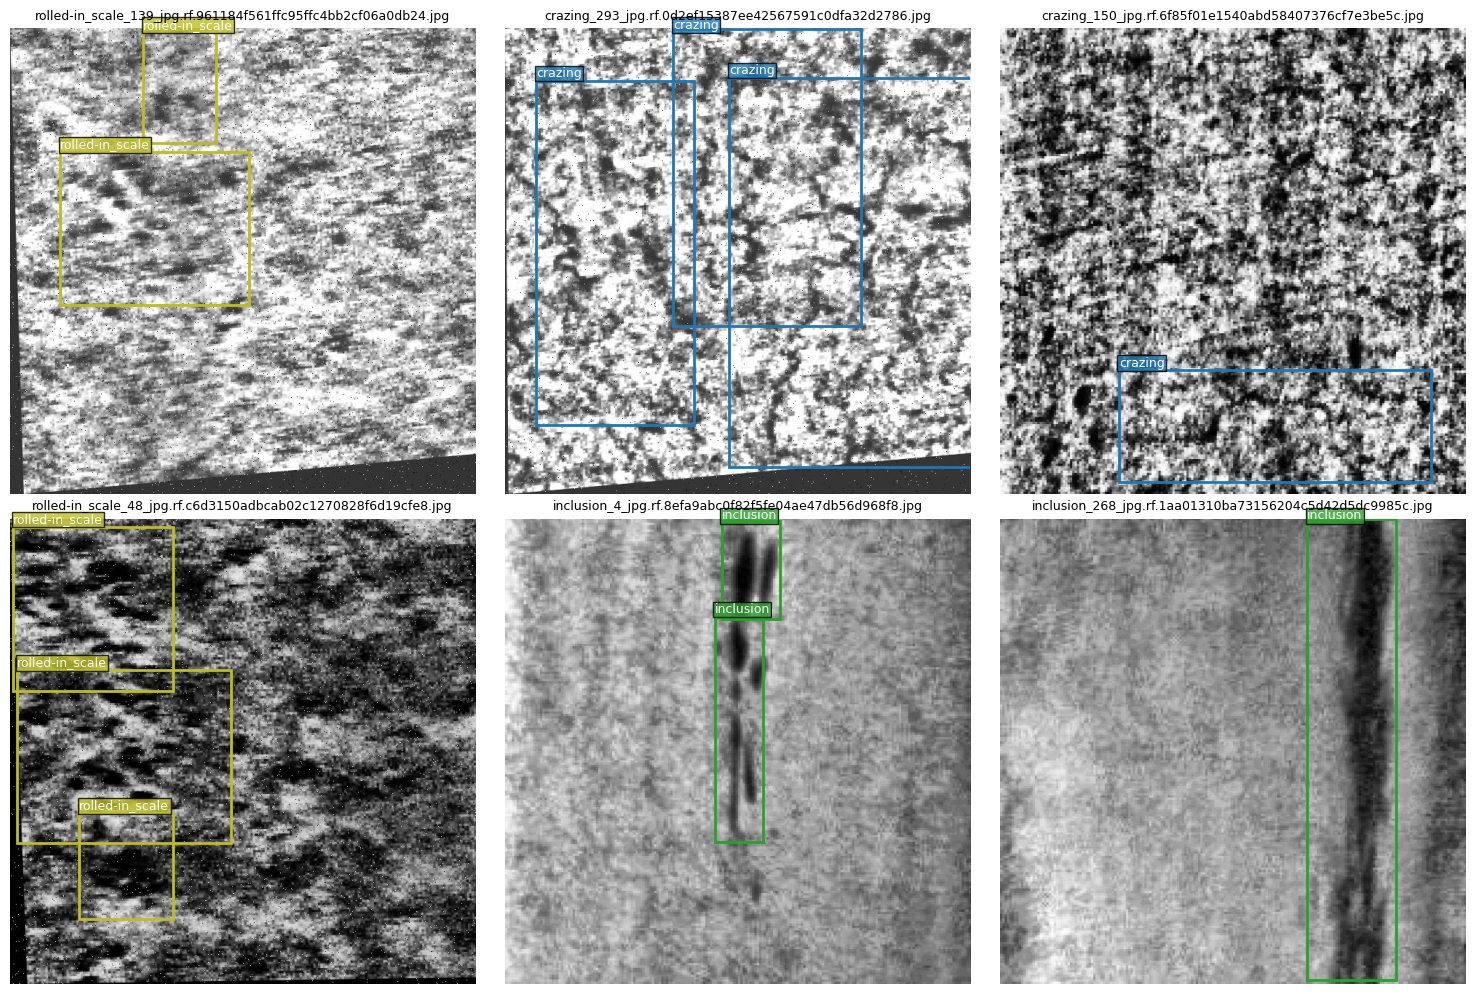

In [56]:
def load_yolo_annotations(label_path: Path, img_w: int, img_h: int) -> list[dict]:
    """Parse a YOLO .txt file into pixel-coordinate boxes."""
    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            class_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])

            # Convert normalised cx,cy,w,h -> pixel x1,y1,x2,y2
            x1 = (cx - w / 2) * img_w
            y1 = (cy - h / 2) * img_h
            x2 = (cx + w / 2) * img_w
            y2 = (cy + h / 2) * img_h

            boxes.append({
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
                "bbox": [x1, y1, x2, y2],
            })
    return boxes


def show_sample_images(split: str = "train", n: int = 6, seed: int = 42):
    # FIXED: Map 'val' to 'valid' and correct the Roboflow path structure
    folder_name = "valid" if split == "val" else split
    img_dir = DATASET_ROOT / folder_name / "images"
    label_dir = DATASET_ROOT / folder_name / "labels"

    # Added safety check just in case the folder is empty
    if not img_dir.exists():
        print(f"❌ Error: Image directory not found at {img_dir.resolve()}")
        return

    image_files = sorted([f for f in img_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")])
    
    if not image_files:
        print(f"⚠️ Warning: No images found in {img_dir.name}")
        return

    random.seed(seed)
    sample = random.sample(image_files, min(n, len(image_files)))

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

    for ax, img_path in zip(axes, sample):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = label_dir / (img_path.stem + ".txt")
        boxes = load_yolo_annotations(label_path, w, h)

        ax.imshow(img)
        for box in boxes:
            x1, y1, x2, y2 = box["bbox"]
            color = colors[box["class_id"] % len(colors)] # Guard against index errors
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 5, 0), box["class_name"],
                    color="white", fontsize=9, bbox=dict(facecolor=color, alpha=0.8, pad=1))

        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images("train", n=6)

## Image size / aspect ratio check


In [57]:
def check_image_dimensions(split: str = "train", sample_size: int = 50):
    # FIXED: Map 'val' to 'valid' and correct the path order
    folder_name = "valid" if split == "val" else split
    img_dir = DATASET_ROOT / folder_name / "images"
    
    # Safety check to prevent crashes if the path is missing
    if not img_dir.exists():
        print(f"❌ Error: Image directory not found at {img_dir.resolve()}")
        return

    image_files = [f for f in img_dir.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")]
    
    if not image_files:
        print(f"⚠️ Warning: No images found in {img_dir.name}")
        return
        
    sample = random.sample(image_files, min(sample_size, len(image_files)))

    dims = []
    for img_path in sample:
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        dims.append((w, h))

    df = pd.DataFrame(dims, columns=["width", "height"])
    print(f"Sampled {len(df)} images from '{split}':")
    print(df.describe())

    unique_sizes = df.drop_duplicates()
    if len(unique_sizes) == 1:
        print(f"\n✓ All sampled images are {unique_sizes.iloc[0]['width']}x{unique_sizes.iloc[0]['height']}")
    else:
        print(f"\n⚠ {len(unique_sizes)} distinct image sizes found — YOLO26 will resize all to imgsz=640")

check_image_dimensions("train")

Sampled 50 images from 'train':
       width  height
count   50.0    50.0
mean   640.0   640.0
std      0.0     0.0
min    640.0   640.0
25%    640.0   640.0
50%    640.0   640.0
75%    640.0   640.0
max    640.0   640.0

✓ All sampled images are 640x640


##  Smoke Test — Quick 3-Epoch Run

Before committing to a full 50-epoch run, A 3-epoch smoke test. This confirms:
- `data.yaml` paths are correct
- Labels load without errors
- Training loop runs end-to-end
- You can estimate time-per-epoch to plan the full run

In [58]:
# Use the absolute path to data.yaml from the Roboflow export
DATA_YAML_PATH = str(DATA_YAML.resolve())

smoke_model = YOLO("yolo26n.pt")

smoke_results = smoke_model.train(
    data=DATA_YAML_PATH,
    epochs=3,
    imgsz=320,
    batch=8,
    fraction=0.1, 
    project="runs_notebook",
    name="smoke_test",
    exist_ok=True,
    device="cpu",   # change to "0" if you have a GPU
    verbose=True,
    workers=0
)

print("\nSmoke test complete.")
print(f"mAP50 after 3 epochs: {smoke_results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
print("(Low mAP50 is expected after only 3 epochs — this just confirms the pipeline runs.)")

Ultralytics 8.4.66 🚀 Python-3.12.4 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/apple/FactoryEye-Real-Time-AI-Defect-Detection-System-1/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_test, nbs=64, nms=False, opset=None, optimize=False

# Full Training Run (50 Epochs) with MLflow Logging

This is the real training run. It mirrors `training/train.py` 

- MLflow server in a terminal:
  ```bash
  mlflow server --host 0.0.0.0 --port 5000 \
    --backend-store-uri ../mlflow_tracking/mlruns \
    --default-artifact-root ../mlflow_tracking/artifacts
  ```

In [59]:
# ── Training configuration ──────────────────────────────────────────────────
BASE_MODEL    = "yolo26n.pt"
EPOCHS        = 50
IMAGE_SIZE    = 640
BATCH_SIZE    = 16
LEARNING_RATE = 0.01
DEVICE        = "cpu"   # change to "0" for GPU
PROJECT_DIR   = "runs_notebook"
RUN_NAME      = "train_full"

REGISTER_THRESHOLD = 0.70   # only register model in MLflow if mAP50 >= this

# ── MLflow setup ─────────────────────────────────────────────────────────────
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("defect-detection")

print("Configuration set. Run the next cell to start training.")

MlflowException: API request to endpoint /api/2.0/mlflow/experiments/get-by-name failed with error code 403 != 200. Response body: ''